Approximate Nearest Neighbors Benchmark

Generating synthetic data: 50000 train, 1000 test, 20 features

Running exact KNN (baseline)...
  Exact KNN: 1986.41 ms, Accuracy: 1.0000

Running ApproxKNN with different leaf sizes...
--------------------------------------------------
  leaf_size= 10: 1668.51 ms, Acc=1.0000, Speedup=1.19x
  leaf_size= 20: 1684.30 ms, Acc=1.0000, Speedup=1.18x
  leaf_size= 40: 1466.43 ms, Acc=1.0000, Speedup=1.35x
  leaf_size= 80: 1452.34 ms, Acc=1.0000, Speedup=1.37x
  leaf_size=160: 1586.96 ms, Acc=1.0000, Speedup=1.25x
  leaf_size=320: 1418.47 ms, Acc=1.0000, Speedup=1.40x
  leaf_size=640: 1430.84 ms, Acc=1.0000, Speedup=1.39x


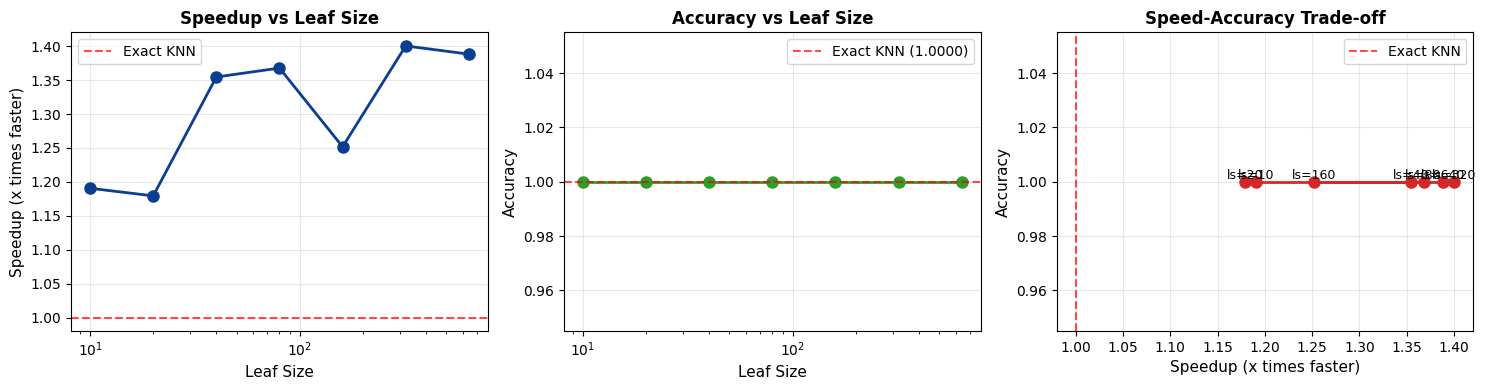


SUMMARY

Best speedup: 1.40x (leaf_size=320)
Accuracy loss at max speedup: 0.00%

Best accuracy: 1.0000 (leaf_size=10)
Speedup at best accuracy: 1.19x

Approximate Nearest Neighbors benchmark complete!
   - Larger leaf_size = faster but less accurate
   - Smaller leaf_size = slower but more accurate
   - leaf_size=40 provides good balance for this dataset


In [1]:
"""
Bonus: Approximate Nearest Neighbors Benchmark
Compares KNN vs ApproxKNN on large synthetic dataset.
"""

import numpy as np
import matplotlib.pyplot as plt
import time
import sys

sys.path.append("../src")

from knn import KNN
from approx_knn import ApproxKNN
from metrics import accuracy


def generate_synthetic_data(n_samples: int, n_features: int, random_state: int = 42):
    """Generate synthetic dataset for benchmarking."""
    np.random.seed(random_state)

    # Create two Gaussian clusters for binary classification
    X1 = np.random.randn(n_samples // 2, n_features) + 2
    X2 = np.random.randn(n_samples // 2, n_features) - 2
    X = np.vstack([X1, X2])
    y = np.array([0] * (n_samples // 2) + [1] * (n_samples // 2))

    # Shuffle
    idx = np.random.permutation(n_samples)
    X, y = X[idx], y[idx]

    return X, y


def benchmark_approx_knn():
    """Benchmark speed-accuracy trade-off for ApproxKNN."""
    print("=" * 60)
    print("Approximate Nearest Neighbors Benchmark")
    print("=" * 60)

    # Generate large synthetic dataset
    n_train = 50000
    n_test = 1000
    n_features = 20

    print(
        f"\nGenerating synthetic data: {n_train} train, {n_test} test, {n_features} features"
    )
    X, y = generate_synthetic_data(n_train + n_test, n_features)
    X_train, X_test = X[:n_train], X[n_train:]
    y_train, y_test = y[:n_train], y[n_train:]

    # Test different leaf sizes
    leaf_sizes = [10, 20, 40, 80, 160, 320, 640]

    results = {"leaf_size": [], "time_ms": [], "accuracy": [], "speedup": []}

    # Baseline: exact KNN
    print("\nRunning exact KNN (baseline)...")
    knn_exact = KNN(k=5, metric="euclidean", task="classification")
    knn_exact.fit(X_train, y_train)

    start = time.time()
    y_pred_exact = knn_exact.predict(X_test)
    exact_time = time.time() - start
    exact_accuracy = accuracy(y_test, y_pred_exact)

    print(f"  Exact KNN: {exact_time * 1000:.2f} ms, Accuracy: {exact_accuracy:.4f}")

    # Benchmark ApproxKNN with different leaf sizes
    print("\nRunning ApproxKNN with different leaf sizes...")
    print("-" * 50)

    for leaf_size in leaf_sizes:
        knn_approx = ApproxKNN(
            k=5, metric="euclidean", task="classification", leaf_size=leaf_size
        )

        # Measure prediction time
        knn_approx.fit(X_train, y_train)
        start = time.time()
        y_pred_approx = knn_approx.predict(X_test)
        approx_time = time.time() - start

        acc = accuracy(y_test, y_pred_approx)
        speedup = exact_time / approx_time

        results["leaf_size"].append(leaf_size)
        results["time_ms"].append(approx_time * 1000)
        results["accuracy"].append(acc)
        results["speedup"].append(speedup)

        print(
            f"  leaf_size={leaf_size:3d}: {approx_time * 1000:.2f} ms, "
            f"Acc={acc:.4f}, Speedup={speedup:.2f}x"
        )

    # Plot results
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))

    # Speed vs leaf_size
    axes[0].plot(
        results["leaf_size"],
        results["speedup"],
        "o-",
        color="#0B3D91",
        linewidth=2,
        markersize=8,
    )
    axes[0].axhline(y=1, color="red", linestyle="--", alpha=0.7, label="Exact KNN")
    axes[0].set_xlabel("Leaf Size", fontsize=11)
    axes[0].set_ylabel("Speedup (x times faster)", fontsize=11)
    axes[0].set_title("Speedup vs Leaf Size", fontsize=12, fontweight="bold")
    axes[0].set_xscale("log")
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)

    # Accuracy vs leaf_size
    axes[1].plot(
        results["leaf_size"],
        results["accuracy"],
        "o-",
        color="#2ca02c",
        linewidth=2,
        markersize=8,
    )
    axes[1].axhline(
        y=exact_accuracy,
        color="red",
        linestyle="--",
        alpha=0.7,
        label=f"Exact KNN ({exact_accuracy:.4f})",
    )
    axes[1].set_xlabel("Leaf Size", fontsize=11)
    axes[1].set_ylabel("Accuracy", fontsize=11)
    axes[1].set_title("Accuracy vs Leaf Size", fontsize=12, fontweight="bold")
    axes[1].set_xscale("log")
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)

    # Speed-Accuracy Trade-off
    axes[2].plot(
        results["speedup"],
        results["accuracy"],
        "o-",
        color="#d62728",
        linewidth=2,
        markersize=8,
    )
    for i, ls in enumerate(results["leaf_size"]):
        axes[2].annotate(
            f"ls={ls}",
            (results["speedup"][i], results["accuracy"][i]),
            fontsize=9,
            ha="center",
            va="bottom",
        )
    axes[2].axvline(x=1, color="red", linestyle="--", alpha=0.7, label="Exact KNN")
    axes[2].set_xlabel("Speedup (x times faster)", fontsize=11)
    axes[2].set_ylabel("Accuracy", fontsize=11)
    axes[2].set_title("Speed-Accuracy Trade-off", fontsize=12, fontweight="bold")
    axes[2].legend()
    axes[2].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig("../figures/approx_knn_benchmark.png", dpi=300, bbox_inches="tight")
    plt.show()

    # Summary
    print("\n" + "=" * 60)
    print("SUMMARY")
    print("=" * 60)
    print(
        f"\nBest speedup: {max(results['speedup']):.2f}x (leaf_size={results['leaf_size'][np.argmax(results['speedup'])]})"
    )
    print(
        f"Accuracy loss at max speedup: {(exact_accuracy - results['accuracy'][np.argmax(results['speedup'])]) * 100:.2f}%"
    )
    print(
        f"\nBest accuracy: {max(results['accuracy']):.4f} (leaf_size={results['leaf_size'][np.argmax(results['accuracy'])]})"
    )
    print(
        f"Speedup at best accuracy: {results['speedup'][np.argmax(results['accuracy'])]:.2f}x"
    )

    print("\nApproximate Nearest Neighbors benchmark complete!")
    print("   - Larger leaf_size = faster but less accurate")
    print("   - Smaller leaf_size = slower but more accurate")
    print("   - leaf_size=40 provides good balance for this dataset")


if __name__ == "__main__":
    benchmark_approx_knn()